In [104]:
import numpy as np


class LogisticRegressionGD:
    def __init__(self, learning_rate=0.01, n_iter=100):
        self.learning_rate = learning_rate
        self.n_iter = n_iter
        self.losses = []

    def fit(self, X, y_true):
        self.weights = np.zeros(X.shape[1])
        self.bias = np.zeros(1)

        for i in range(self.n_iter):
            z = self.net_input(X)
            output = self.activate(z)
            d_loss__d_a = (y_true - output)
            self.weights += self.learning_rate * X.T.dot(d_loss__d_a) / X.shape[0]
            self.bias += self.learning_rate * d_loss__d_a.mean()
            loss = (-y_true.dot(np.log(output))
                    - ((1 - y_true).dot(np.log(1 - output))) / X.shape[0])
            self.losses.append(loss)
        return self

    def net_input(self, X):
        return np.dot(X, self.weights) + self.bias

    def activate(self, net_input):
        return 1. / (1. + np.exp(-np.clip(net_input, -250, 250)))

    def predict(self, X):
        return np.where(self.activate(self.net_input(X)) >= 0.5, 1, 0)


In [105]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris = load_iris()
X = iris.data[:100, :2]
y = iris.target[:100]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42,
                                                    stratify=y, test_size=0.3)
model = LogisticRegressionGD(learning_rate=0.3, n_iter=1000)
model = model.fit(X_train, y_train)

In [106]:
y_predicted = model.predict(X_test)
print(model.weights)
print(y_predicted)

[ 4.28415813 -7.11456565]
[0 0 1 0 0 1 1 0 1 0 1 1 0 0 1 1 0 0 1 0 0 0 1 1 0 0 1 1 1 0]


In [107]:
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt


def plot_decision_regions(X, y, classifier, resolution=0.02, test_idx=None):
    markers = ['o', 's', '^', 'v', '<']
    colors = ['red', 'blue', 'green', 'cyan', 'grey']
    cmap = ListedColormap(colors[:len(np.unique(y))])

    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))
    lab = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    lab = lab.reshape(xx1.shape)
    plt.contourf(xx1, xx2, lab, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0],
                    y=X[y == cl, 1],
                    alpha=0.8,
                    c=colors[idx],
                    marker=markers[idx],
                    edgecolors='black',
                    label=f"Класс {cl}")

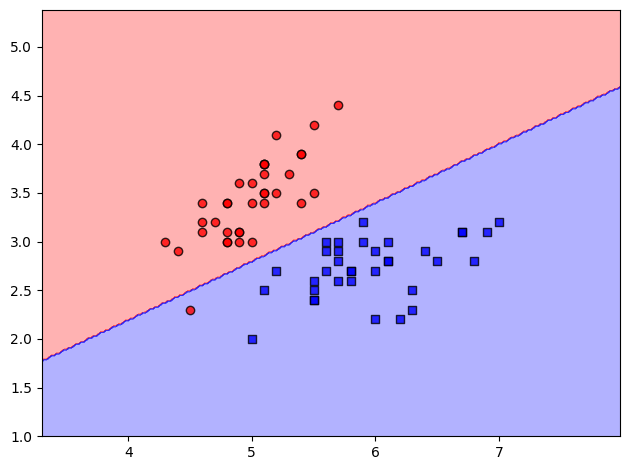

In [108]:
plot_decision_regions(X=X_train, y=y_train, classifier=model)
plt.tight_layout()
plt.show()